<h1>IMPORTAÇÕES</h1>


In [1]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse

from sklearn.preprocessing import MinMaxScaler, StandardScaler

def total_mean_error(predictions):
    mean_error = []

    for i in range(len(predictions)):
        if df['Normalized'][i] == 0:
            error_value = np.abs((predictions[i]-0.01)/(0.01))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )
        else:
            error_value = np.abs((predictions[i]-df['Normalized'][i])/(df['Normalized'][i]))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )

    aux = 0

    for i in range(len(mean_error)):
        if mean_error[i] > 200:
            aux = aux
        else:
            aux = mean_error[i] + aux

    final_mean = aux/len(mean_error)

    print(f"Erro percentual médio = {final_mean}%")

<h1>TRATAMENTO DE DADOS</h1>


In [2]:
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df.head

<bound method NDFrame.head of            3003858507 3001084033 3011373971 3001449459 3011504476
idx                                                              
2019-06-01     1246.0     7160.0      440.0      960.0     1560.0
2019-07-01     1081.0     6520.0      600.0      920.0     1280.0
2019-08-01     1184.0     6840.0      680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0      760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0      560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0      520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0      320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0      440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0      280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0      320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0      440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0        0.0     1040.0     1280.0
2020-06-01     1174.0     5080.0        0.0   

<h1>NORMALIZAÇÃO DOS DADOS</h1>


In [3]:
values = df[3003858507].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)
for i in range(5):
    print(df_normalized[i])

[0.17729522]
[0.13194063]
[0.16025289]
[0.26058274]
[0.39692139]


In [4]:
df["Normalized"] = df_normalized

In [5]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   45
Model:               SARIMAX(2, 0, 2)   Log Likelihood                   9.565
Date:                Tue, 04 Jun 2024   AIC                             -7.131
Time:                        15:00:45   BIC                              3.709
Sample:                    06-01-2019   HQIC                            -3.090
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0783      0.022      3.607      0.000       0.036       0.121
ar.L1          1.7067      0.111     15.442      0.000       1.490       1.923
ar.L2         -0.8804      0.128     -6.855      0.000      -1.132      -0.629
ma.L1         -1.3649      0.233     -5.859      0.000      -1.822      -0.908
ma.L2          0.3868      0.209      1.847      0.065      -0.024       0.797
sigma2         0.0356      0.010      3.743      0.000       0.017       0.054
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 2.67
Prob(Q):                              0.83   Prob(JB):                         0.26
Heteroskedasticity (H):               0.52   Skew:                             0.59
Prob(H) (two-sided):                  0.22   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
train = df.iloc[:40]
test = df.iloc[40:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train["Normalized"], order=(2, 0, 2), seasonal_order=(1, 1, 5, 12))
results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.01868D-02    |proj g|=  1.29881D-01

At iterate    5    f=  5.39979D-02    |proj g|=  1.29802D-01

At iterate   10    f=  3.25882D-03    |proj g|=  7.90957D-02

At iterate   15    f= -1.25692D-02    |proj g|=  2.17515D-01

At iterate   20    f= -2.18233D-02    |proj g|=  3.31581D-02

At iterate   25    f= -2.38327D-02    |proj g|=  3.80814D-03

At iterate   30    f= -2.42656D-02    |proj g|=  3.61412D-02

At iterate   35    f= -2.59883D-02    |proj g|=  3.65693D-02

At iterate   40    f= -2.85211D-02    |proj g|=  2.10714D-02

At iterate   45    f= -2.85975D-02    |proj g|=  1.77103D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = nu

In [7]:
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

total_mean_error(normalized_predictions)

predição=0.0, esperado=0.1772952171522815, erro=100.0%
predição=8.50854701080703e-09, esperado=0.13194062671797693, erro=99.99999355123042%
predição=1.1326958589615081e-08, esperado=0.16025288620120945, erro=99.99999293182242%
predição=1.0829418959371014e-08, esperado=0.26058273776800445, erro=99.99999584415336%
predição=1.1207336755017604e-08, esperado=0.3969213853765806, erro=99.99999717643414%
predição=1.46814957391985e-08, esperado=0.9389774601429358, erro=99.99999843643789%
predição=3.984603385828841e-08, esperado=0.49065420560747663, erro=99.99999187899881%
predição=2.9306009764482298e-08, esperado=1.0, erro=99.99999706939903%
predição=3.404426955412097e-08, esperado=0.6192963166575042, erro=99.99999450274956%
predição=1.1494022927129743e-08, esperado=0.7166025288620121, erro=99.9999983960393%
predição=-4.924642004789016e-09, esperado=0.12286970863111599, erro=100.0000040080196%
predição=-4.030664698034838e-08, esperado=0.19571192963166575, erro=100.00002059488509%
predição=0.177

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

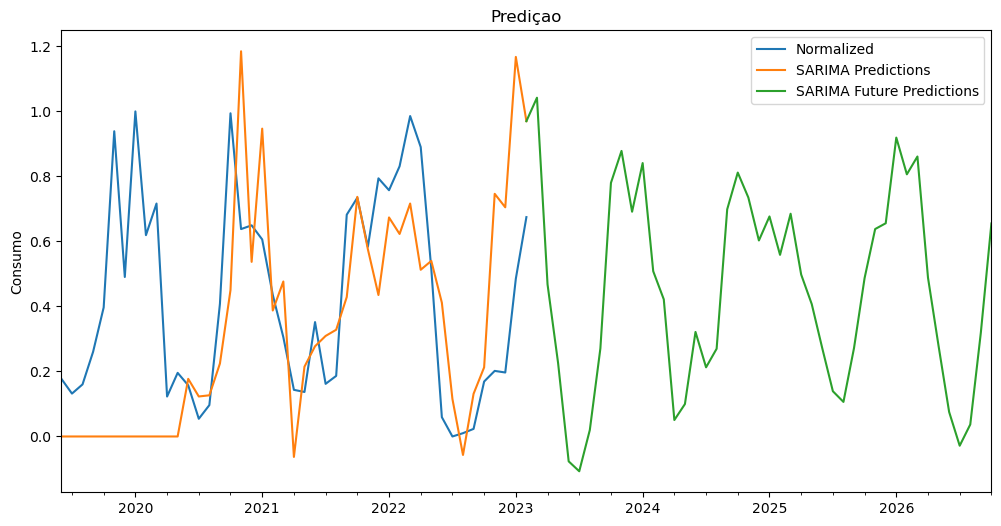

In [8]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [9]:
values = normalized_predictions.values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df["inversed"] = inversed

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

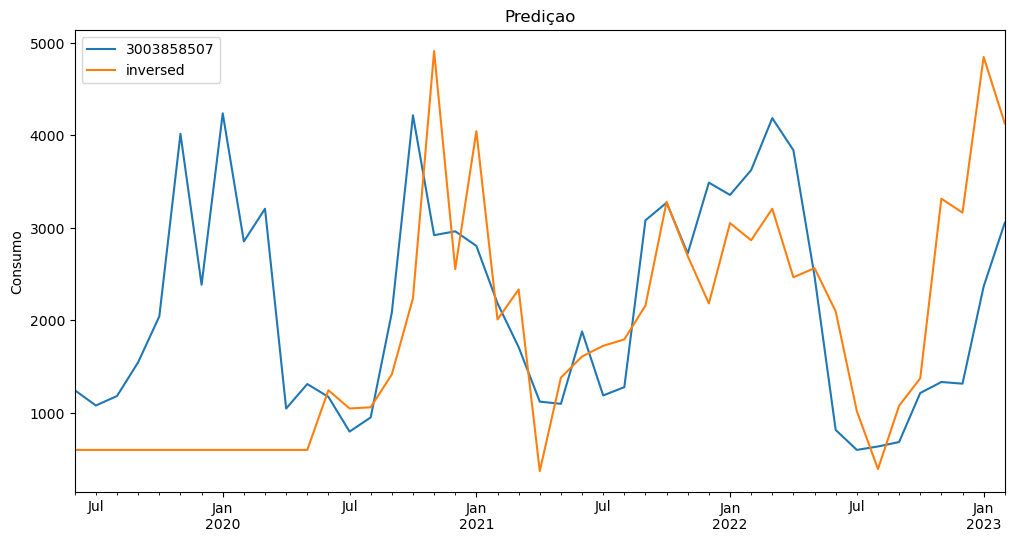

In [10]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
ax2 = df["inversed"].plot(legend=True, figsize=(12, 6), title=title)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [11]:
error = rmse(df[3003858507], df['inversed'])
print(f'SARIMA(0,1,3)(1,0,1,12) RMSE Error: {error:11.10}')

SARIMA(0,1,3)(1,0,1,12) RMSE Error: 1326.847074


In [12]:
model = SARIMAX(
    df[3003858507].astype(float), order=(2, 0, 2), seasonal_order=(1, 1, 5, 12)
)
results = model.fit()

predictions = results.predict(start=0, end=end, dynamic=False, typ="levels").rename(
    "SARIMA Predictions"
)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.10081D+00    |proj g|=  1.84561D-01


 This problem is unconstrained.



At iterate    5    f=  6.02947D+00    |proj g|=  1.26944D-02

At iterate   10    f=  6.02423D+00    |proj g|=  2.17248D-02

At iterate   15    f=  6.01687D+00    |proj g|=  2.82149D-02

At iterate   20    f=  6.01537D+00    |proj g|=  9.51959D-03

At iterate   25    f=  6.01409D+00    |proj g|=  6.61223D-03

At iterate   30    f=  6.01368D+00    |proj g|=  4.50715D-04

At iterate   35    f=  6.01368D+00    |proj g|=  1.19425D-03

At iterate   40    f=  6.01365D+00    |proj g|=  3.15345D-03

At iterate   45    f=  6.01331D+00    |proj g|=  4.41568D-03

At iterate   50    f=  6.01302D+00    |proj g|=  6.34984D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/home/henrique/miniconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
error = rmse(df[3003858507], predictions)
print(f'SARIMA(0,1,3)(1,0,1,12) RMSE Error: {error:11.10}')

SARIMA(0,1,3)(1,0,1,12) RMSE Error: 1284.360544


[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

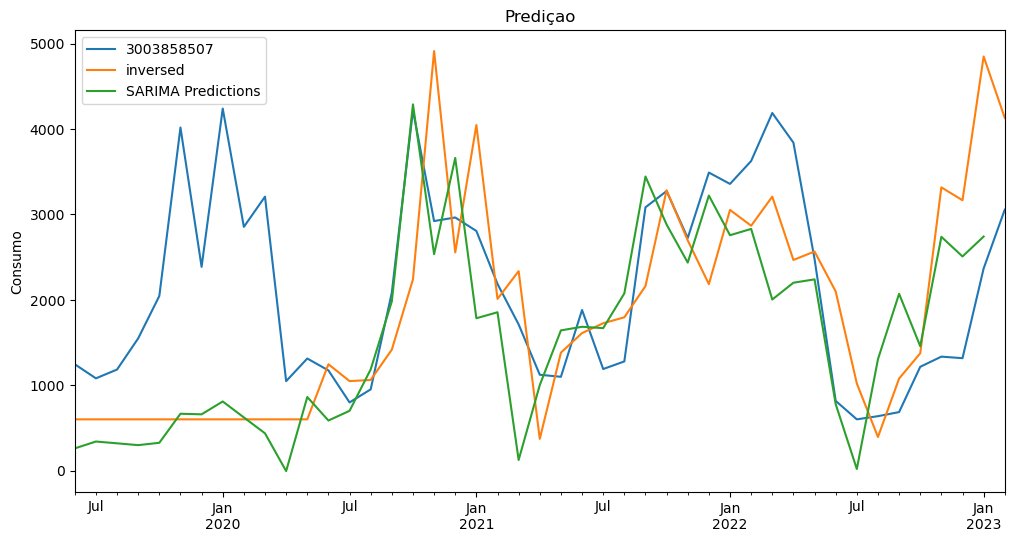

In [14]:
predictions = predictions.shift(-1)

title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
ax2 = df["inversed"].plot(legend=True)
predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [15]:
values = normalized_future_predictions.values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df["inversed"] = inversed

In [16]:
model = SARIMAX(
    df[3003858507].astype(float), order=(2, 0, 2), seasonal_order=(5, 1, 5, 12)
)
results = model.fit()

predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           15     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.10081D+00    |proj g|=  1.84561D-01


 This problem is unconstrained.



At iterate    5    f=  6.02776D+00    |proj g|=  1.24501D-02

At iterate   10    f=  6.01653D+00    |proj g|=  1.69026D-02

At iterate   15    f=  6.01233D+00    |proj g|=  1.13727D-02

At iterate   20    f=  6.01174D+00    |proj g|=  2.59871D-03

At iterate   25    f=  6.01083D+00    |proj g|=  1.82469D-02

At iterate   30    f=  6.01076D+00    |proj g|=  6.38738D-04

At iterate   35    f=  6.01075D+00    |proj g|=  3.60382D-04

At iterate   40    f=  6.01074D+00    |proj g|=  2.03736D-04

At iterate   45    f=  6.01074D+00    |proj g|=  3.34326D-04


/home/henrique/miniconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  6.01073D+00    |proj g|=  1.01030D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   15     50     55      1     0     0   1.010D-03   6.011D+00
  F =   6.0107339094035881     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

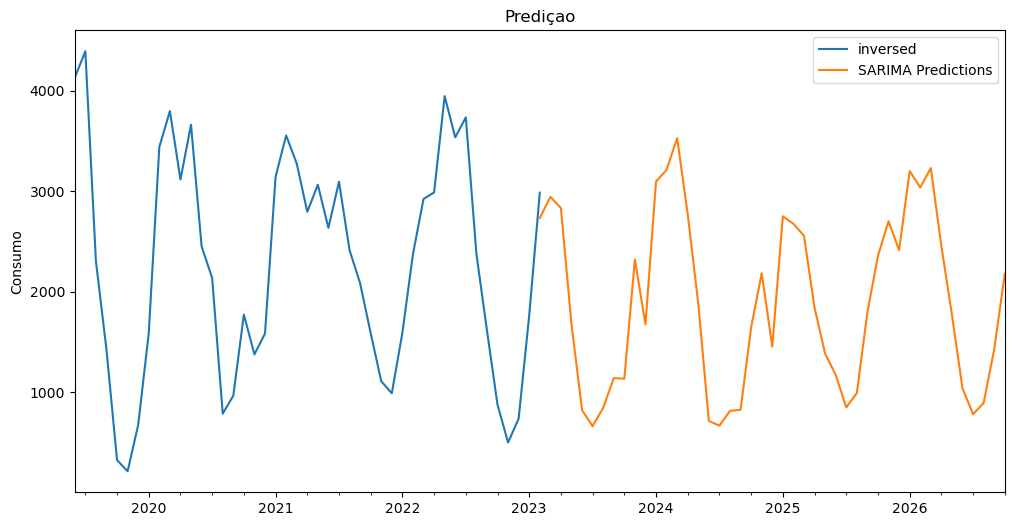

In [17]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["inversed"].plot(legend=True, figsize=(12, 6), title=title)
predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)